<a href="https://colab.research.google.com/github/Agkso/AlgoritmoArvore/blob/main/C%C3%B3pia_de_Aula001_VersaoMinimaParaTrabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  cliente  idade  renda_mensal  valor_emprestimo  tempo_emprego_anos  \
0      C1     50          5113             26662                  20   
1      C2     36          7725             12392                  13   
2      C3     29          6343             34535                   9   
3      C4     42          4000             17067                   3   
4      C5     40          7298             27599                   7   

   score_credito risco_credito  
0            617          alto  
1            603          alto  
2            648         medio  
3            695         baixo  
4            677         baixo  
(50, 7)

Distribuição das classes:
risco_credito
baixo    20
alto     15
medio    15
Name: count, dtype: int64

Classes encontradas: ['alto', 'baixo', 'medio']
Total de linhas válidas: 50

Treino: 38 | Teste: 12

🔵 RESULTADO - KNN
Features usadas: ['idade', 'renda_mensal', 'valor_emprestimo', 'tempo_emprego_anos', 'score_credito']
Acurácia: 0.25

Relatório:
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


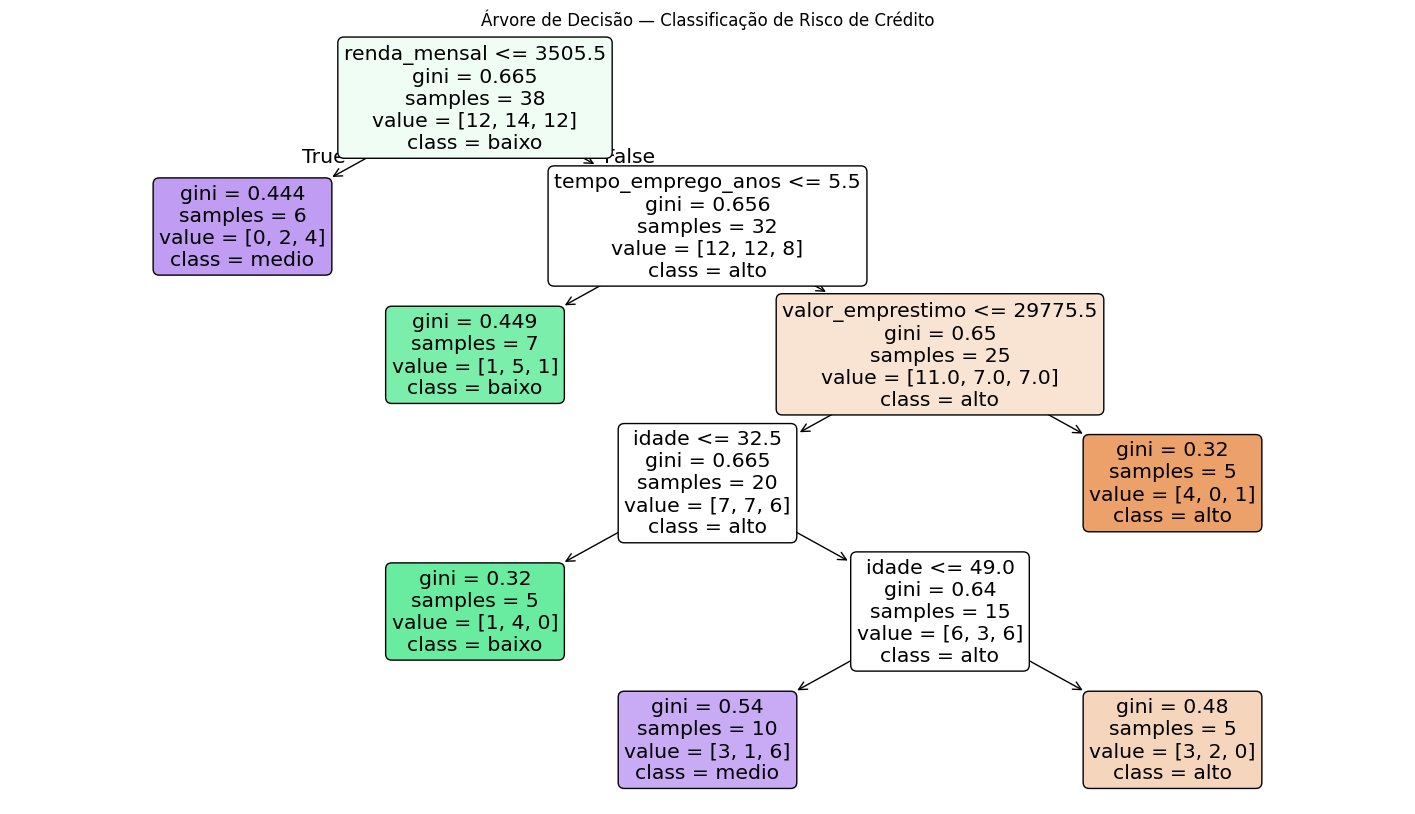

In [ ]:
# ============================================
# PROJETO: Classificação de Risco de Crédito
# Base: Google Sheets
# Modelo: KNN + Árvore de Decisão
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ============================================
# 1️⃣ LEITURA DA PLANILHA
# ============================================

df = pd.read_csv("credito.csv")
print(df.head())
print(df.shape)

# ============================================
# 2️⃣ DEFINIÇÃO DE FEATURES E TARGET
# ============================================

FEATURES = [
    "idade",
    "renda_mensal",
    "valor_emprestimo",
    "tempo_emprego_anos",
    "score_credito"
]

TARGET = "risco_credito"

# ============================================
# 3️⃣ LIMPEZA E PREPARAÇÃO
# ============================================

for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()

df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("\nDistribuição das classes:")
print(df[TARGET].value_counts())

# ============================================
# 4️⃣ ENCODER
# ============================================

le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses encontradas:", list(le.classes_))
print("Total de linhas válidas:", len(df))

# ============================================
# 5️⃣ SHUFFLE E SPLIT (25% TESTE)
# ============================================

RANDOM_STATE = 42

df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

limite_teste = int(len(df) * 0.25)

test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:].copy()

X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])

X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])

print("\nTreino:", len(train_df), "| Teste:", len(test_df))

# ============================================
# 6️⃣ MODELO KNN
# ============================================

K = 9
WEIGHTS = "distance"

knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("\n==============================")
print("🔵 RESULTADO - KNN")
print("==============================")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_knn))
print("\nRelatório:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_knn))

test_df["classe_prevista_knn"] = le.inverse_transform(y_pred_knn)

# ============================================
# 7️⃣ ÁRVORE DE DECISÃO
# ============================================

tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("\n==============================")
print("🌳 RESULTADO - ÁRVORE DE DECISÃO")
print("==============================")
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_tree))

test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)

# ============================================
# 8️⃣ RESULTADO DETALHADO
# ============================================

print("\nResultado detalhado (teste):")
print(test_df[["cliente"] + FEATURES + [TARGET, "classe_prevista_knn", "classe_prevista_arvore"]])

# ============================================
# 9️⃣ VISUALIZAÇÃO DA ÁRVORE
# ============================================

plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)

plt.title("Árvore de Decisão — Classificação de Risco de Crédito")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)  # para reprodutibilidade

n = 50  # número de clientes

# Gerar dados sintéticos
data = {
    "cliente": [f"C{i+1}" for i in range(n)],
    "idade": np.random.randint(22, 60, size=n),
    "renda_mensal": np.random.randint(2500, 9000, size=n),
    "valor_emprestimo": np.random.randint(4000, 40000, size=n),
    "tempo_emprego_anos": np.random.randint(1, 25, size=n),
    "score_credito": np.random.randint(580, 750, size=n),
    "risco_credito": np.random.choice(["baixo", "medio", "alto"], size=n, p=[0.4,0.3,0.3])
}

# Criar DataFrame
df = pd.DataFrame(data)

# Salvar CSV local
df.to_csv("credito.csv", index=False)
print("Arquivo credito.csv gerado com sucesso!")
print(df.head())

Arquivo credito.csv gerado com sucesso!
  cliente  idade  renda_mensal  valor_emprestimo  tempo_emprego_anos  \
0      C1     50          5113             26662                  20   
1      C2     36          7725             12392                  13   
2      C3     29          6343             34535                   9   
3      C4     42          4000             17067                   3   
4      C5     40          7298             27599                   7   

   score_credito risco_credito  
0            617          alto  
1            603          alto  
2            648         medio  
3            695         baixo  
4            677         baixo  
